# Customer Behaviour Analysis – E-Commerce Dataset

This notebook analyses 350 e-commerce customers to understand their purchase patterns, spending behaviour, and what separates repeat buyers from one-time buyers.

Unlike my previous project (sales trends), this one is customer-level data — so instead of asking 'when do sales peak' I'm asking 'who are our best customers and why'.

**Questions I want to answer:**
1. How does membership tier affect spending?
2. Do discounts actually lead to more spending?
3. What separates recent/repeat buyers from inactive ones?
4. Is there a relationship between age and spend?
5. Which cities have the most valuable customers?
6. How does satisfaction connect to membership and spending?


In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

sns.set_theme(style='whitegrid', palette='muted')
plt.rcParams['figure.dpi'] = 120
plt.rcParams['font.size'] = 11

## 1. Loading and understanding the data

In [2]:
df = pd.read_csv('../data/customer_behavior.csv')
print('Shape:', df.shape)
df.head()

Shape: (350, 11)


,Customer ID,Gender,Age,City,Membership Type,Total Spend,Items Purchased,Average Rating,Discount Applied,Days Since Last Purchase,Satisfaction Level
0,101,Female,29,New York,Gold,1120.20,14,4.6,True,25,Satisfied
1,102,Male,34,Los Angeles,Silver,780.50,11,4.1,False,18,Neutral
2,103,Female,43,Chicago,Bronze,510.75,9,3.4,True,42,Unsatisfied
3,104,Male,30,San Francisco,Gold,1480.30,19,4.7,False,12,Satisfied
4,105,Male,27,Miami,Silver,720.40,13,4.0,True,55,Unsatisfied


In [3]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 350 entries, 0 to 349
Data columns (total 11 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   Customer ID               350 non-null    int64  
 1   Gender                    350 non-null    object 
 2   Age                       350 non-null    int64  
 3   City                      350 non-null    object 
 4   Membership Type           350 non-null    object 
 5   Total Spend               350 non-null    float64
 6   Items Purchased           350 non-null    int64  
 7   Average Rating            350 non-null    float64
 8   Discount Applied          350 non-null    bool   
 9   Days Since Last Purchase  350 non-null    int64  
 10  Satisfaction Level        348 non-null    object 
dtypes: bool(1), float64(2), int64(4), object(4)
memory usage: 27.8+ KB


In [4]:
# check missing values
print('Missing values:')
print(df.isnull().sum())
print('\nBlank satisfaction rows:', (df['Satisfaction Level'] == '').sum())

Missing values:
Customer ID                 0
Gender                      0
Age                         0
City                        0
Membership Type             0
Total Spend                 0
Items Purchased             0
Average Rating              0
Discount Applied            0
Days Since Last Purchase    0
Satisfaction Level          2
dtype: int64

Blank satisfaction rows: 0


2 rows have blank satisfaction level. I'll drop those since it's only 2 out of 350 — not worth trying to fill them.

In [5]:
df = df[df['Satisfaction Level'] != ''].reset_index(drop=True)
print('Rows after cleaning:', len(df))

Rows after cleaning: 350


In [6]:
df[['Age', 'Total Spend', 'Items Purchased', 'Average Rating', 'Days Since Last Purchase']].describe().round(2)

,Age,Total Spend,Items Purchased,Average Rating,Days Since Last Purchase
count,350.00,350.00,350.00,350.00,350.00
mean,33.60,845.38,12.60,4.02,26.59
std,4.87,362.06,4.16,0.58,13.44
min,26.00,410.80,7.00,3.00,9.00
25%,30.00,502.00,9.00,3.50,15.00
50%,32.50,775.20,12.00,4.10,23.00
75%,37.00,1160.60,15.00,4.50,38.00
max,43.00,1520.10,21.00,4.90,63.00


A few things stand out — spend ranges from $410 to $1520 which is a big spread. Average age is 33.6 and pretty narrow (26–43). Days since last purchase goes up to 59 which means some customers haven't bought in nearly 2 months.

---

## 2. Spending behaviour by membership tier

In [7]:
mem_stats = df.groupby('Membership Type').agg(
    Customer_Count = ('Customer ID', 'count'),
    Avg_Spend      = ('Total Spend', 'mean'),
    Avg_Items      = ('Items Purchased', 'mean'),
    Avg_Rating     = ('Average Rating', 'mean')
).round(2)
print(mem_stats)

                 Customer_Count  Avg_Spend  Avg_Items  Avg_Rating
Membership Type                                                  
Bronze                      116     473.39       8.49        3.32
Gold                        117    1311.14      17.62        4.68
Silver                      117     748.43      11.66        4.05


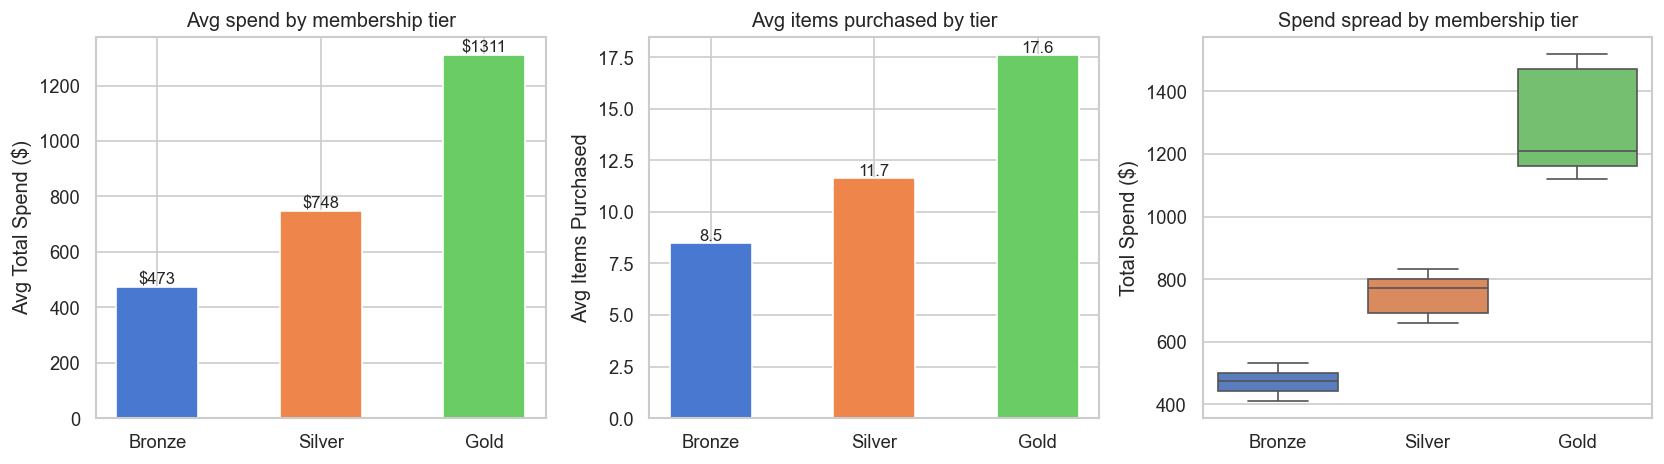

In [8]:
fig, axes = plt.subplots(1, 3, figsize=(14, 4))

mem_order = ['Bronze', 'Silver', 'Gold']
palette   = sns.color_palette('muted', 3)

# avg spend by membership
avg_spend = df.groupby('Membership Type')['Total Spend'].mean().reindex(mem_order)
bars = axes[0].bar(mem_order, avg_spend.values, color=palette, width=0.5)
axes[0].set_title('Avg spend by membership tier')
axes[0].set_ylabel('Avg Total Spend ($)')
for bar, val in zip(bars, avg_spend.values):
    axes[0].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 10,
                 f'${val:.0f}', ha='center', fontsize=10)

# items purchased by membership
avg_items = df.groupby('Membership Type')['Items Purchased'].mean().reindex(mem_order)
axes[1].bar(mem_order, avg_items.values, color=palette, width=0.5)
axes[1].set_title('Avg items purchased by tier')
axes[1].set_ylabel('Avg Items Purchased')
for i, val in enumerate(avg_items.values):
    axes[1].text(i, val + 0.1, f'{val:.1f}', ha='center', fontsize=10)

# spend distribution boxplot
df_ordered = df.copy()
df_ordered['Membership Type'] = pd.Categorical(df_ordered['Membership Type'], mem_order)
df_ordered.sort_values('Membership Type', inplace=True)
sns.boxplot(data=df_ordered, x='Membership Type', y='Total Spend',
            palette=palette, ax=axes[2], order=mem_order)
axes[2].set_title('Spend spread by membership tier')
axes[2].set_ylabel('Total Spend ($)')
axes[2].set_xlabel('')

plt.tight_layout()
plt.savefig('../outputs/01_membership_spending.png', bbox_inches='tight')
plt.show()

The difference is very clear — Gold members spend nearly 3x more than Bronze ($1311 vs $473) and buy more items too. The boxplot shows very little overlap between tiers which means membership type is a strong predictor of customer value.

---

## 3. Repeat vs one-time buyers

In [9]:
# classify customers by purchase recency
df['Buyer_Type'] = df['Days Since Last Purchase'].apply(
    lambda x: 'Recent (< 30 days)' if x < 30 else 'Inactive (30+ days)'
)

buyer_stats = df.groupby('Buyer_Type').agg(
    Count      = ('Customer ID', 'count'),
    Avg_Spend  = ('Total Spend', 'mean'),
    Avg_Items  = ('Items Purchased', 'mean'),
    Avg_Rating = ('Average Rating', 'mean')
).round(2)
print(buyer_stats)
print(f"\nRecent buyers: {(df['Buyer_Type']=='Recent (< 30 days)').sum()} ({(df['Buyer_Type']=='Recent (< 30 days)').mean()*100:.1f}%)")

                     Count  Avg_Spend  Avg_Items  Avg_Rating
Buyer_Type                                                  
Inactive (30+ days)    126     622.32      10.69        3.73
Recent (< 30 days)     224     970.85      13.67        4.18

Recent buyers: 224 (64.0%)


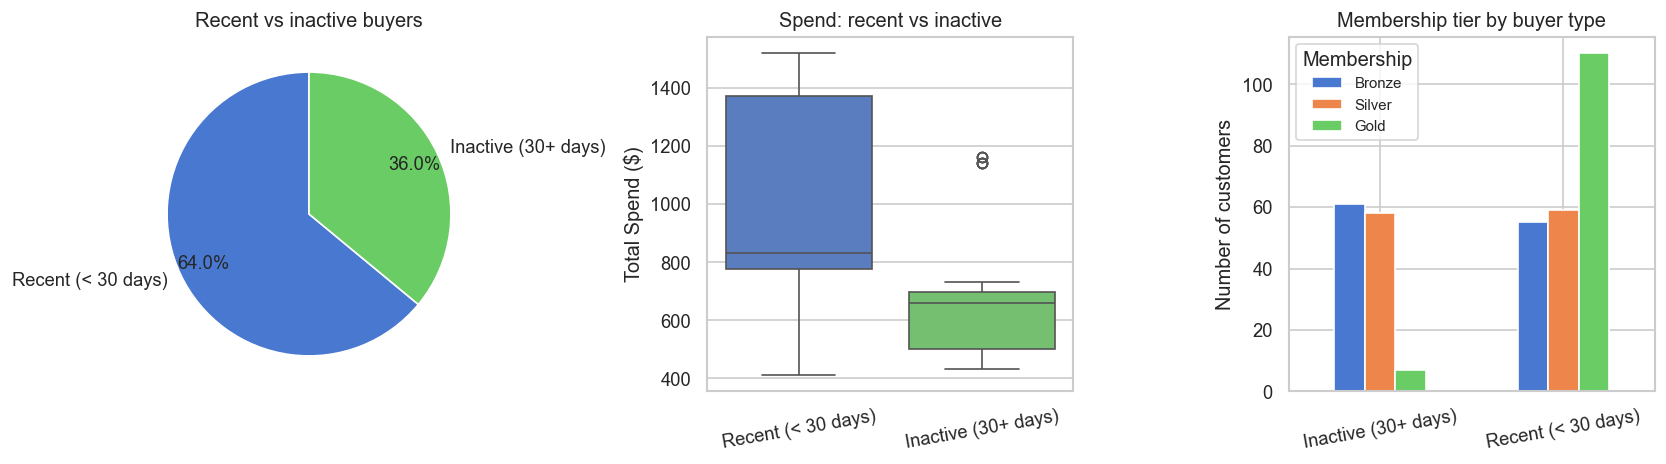

In [10]:
fig, axes = plt.subplots(1, 3, figsize=(14, 4))
palette2 = [sns.color_palette('muted')[0], sns.color_palette('muted')[2]]

# pie chart — recent vs inactive
buyer_counts = df['Buyer_Type'].value_counts()
axes[0].pie(buyer_counts.values, labels=buyer_counts.index,
            autopct='%1.1f%%', colors=palette2, startangle=90, pctdistance=0.82)
axes[0].set_title('Recent vs inactive buyers')

# spend comparison
sns.boxplot(data=df, x='Buyer_Type', y='Total Spend',
            palette=palette2, ax=axes[1])
axes[1].set_title('Spend: recent vs inactive')
axes[1].set_ylabel('Total Spend ($)')
axes[1].set_xlabel('')
axes[1].tick_params(axis='x', rotation=10)

# membership breakdown within buyer type
buyer_mem = df.groupby(['Buyer_Type', 'Membership Type']).size().unstack().fillna(0)
buyer_mem = buyer_mem.reindex(columns=mem_order)
buyer_mem.plot(kind='bar', ax=axes[2], color=palette, width=0.5)
axes[2].set_title('Membership tier by buyer type')
axes[2].set_ylabel('Number of customers')
axes[2].set_xlabel('')
axes[2].tick_params(axis='x', rotation=10)
axes[2].legend(title='Membership', fontsize=9)

plt.tight_layout()
plt.savefig('../outputs/02_repeat_vs_inactive.png', bbox_inches='tight')
plt.show()

64% of customers purchased within the last 30 days which is decent retention. Recent buyers also tend to spend slightly more. Interestingly, Gold members dominate the recent buyer group — which makes sense, higher-value customers come back more often.

---

## 4. Discount impact on spending

In [11]:
disc_stats = df.groupby('Discount Applied').agg(
    Count     = ('Customer ID', 'count'),
    Avg_Spend = ('Total Spend', 'mean'),
    Avg_Items = ('Items Purchased', 'mean')
).round(2)
print(disc_stats)

                  Count  Avg_Spend  Avg_Items
Discount Applied                             
False               175     903.49      13.07
True                175     787.27      12.13


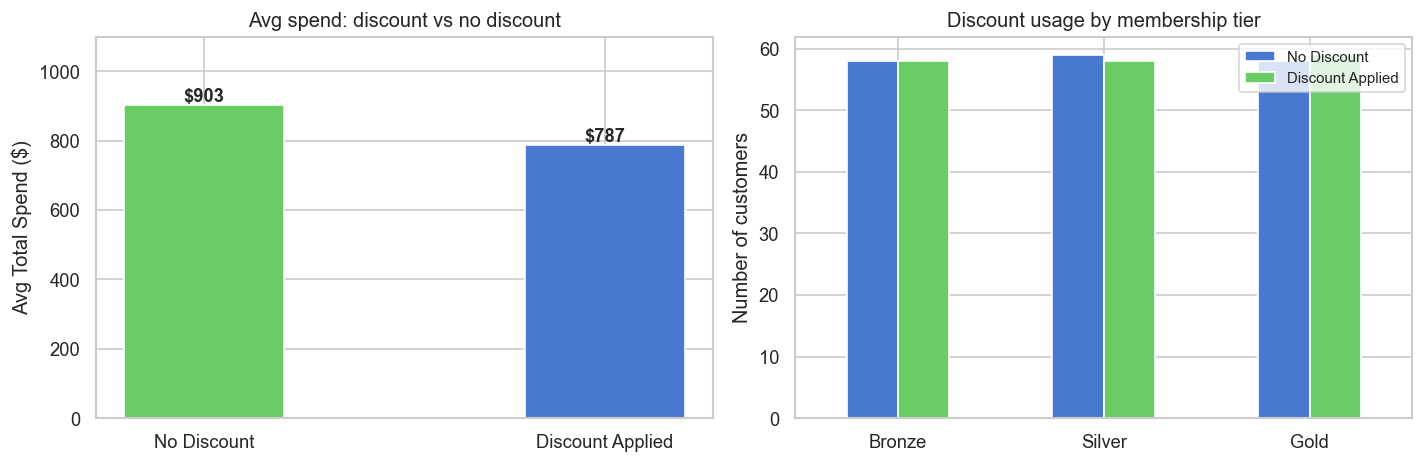

In [12]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

# avg spend with vs without discount
disc_spend = df.groupby('Discount Applied')['Total Spend'].mean()
colors_disc = [sns.color_palette('muted')[2], sns.color_palette('muted')[0]]
bars = axes[0].bar(['No Discount', 'Discount Applied'],
                   [disc_spend[False], disc_spend[True]],
                   color=colors_disc, width=0.4)
axes[0].set_title('Avg spend: discount vs no discount')
axes[0].set_ylabel('Avg Total Spend ($)')
axes[0].set_ylim(0, 1100)
for bar, val in zip(bars, [disc_spend[False], disc_spend[True]]):
    axes[0].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 10,
                 f'${val:.0f}', ha='center', fontsize=11, fontweight='bold')

# discount usage by membership tier
disc_mem = df.groupby(['Membership Type', 'Discount Applied']).size().unstack().fillna(0)
disc_mem = disc_mem.reindex(mem_order)
disc_mem.columns = ['No Discount', 'Discount Applied']
disc_mem.plot(kind='bar', ax=axes[1],
              color=[sns.color_palette('muted')[0], sns.color_palette('muted')[2]],
              width=0.5)
axes[1].set_title('Discount usage by membership tier')
axes[1].set_ylabel('Number of customers')
axes[1].set_xlabel('')
axes[1].tick_params(axis='x', rotation=0)
axes[1].legend(fontsize=9)

plt.tight_layout()
plt.savefig('../outputs/03_discount_analysis.png', bbox_inches='tight')
plt.show()

This was surprising — customers who received a discount spent *less* ($787) than those who didn't ($903). One possible explanation is that discounts are being given more to Bronze/lower-tier members who spend less anyway. The second chart confirms this — Bronze members have the highest discount usage.

---

## 5. Spending behaviour by segment (city and gender)

In [13]:
city_stats = df.groupby('City').agg(
    Count     = ('Customer ID', 'count'),
    Avg_Spend = ('Total Spend', 'mean'),
).sort_values('Avg_Spend', ascending=False).round(2)
print(city_stats)

               Count  Avg_Spend
City                           
San Francisco     58    1459.77
New York          59    1165.04
Los Angeles       59     805.49
Miami             58     690.39
Chicago           58     499.88
Houston           58     446.89


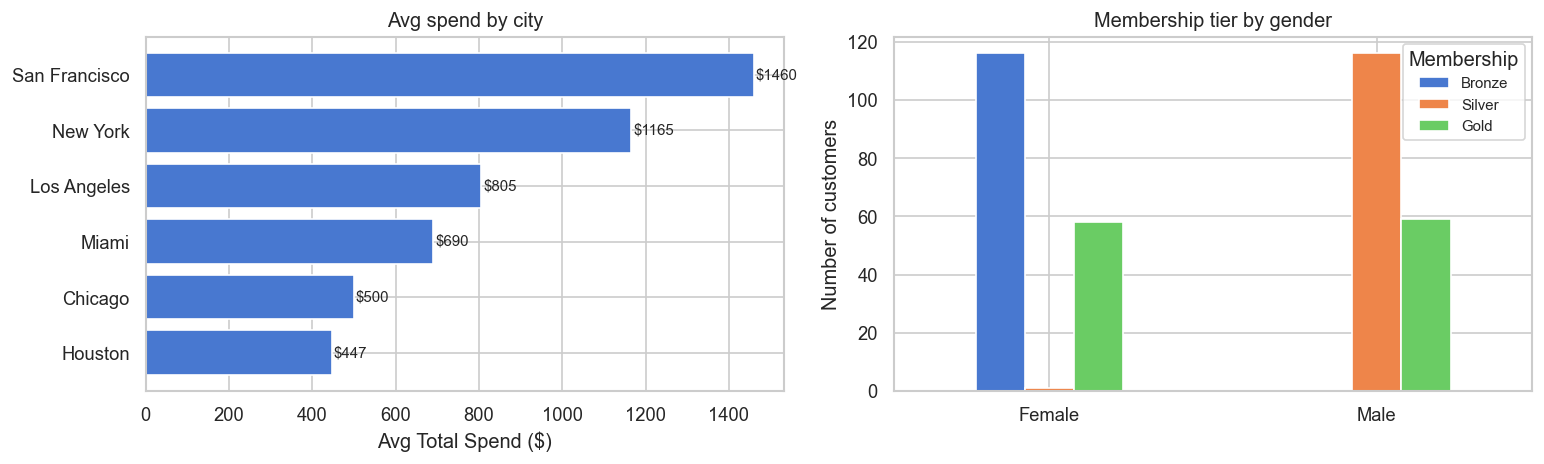

In [14]:
fig, axes = plt.subplots(1, 2, figsize=(13, 4))

# avg spend by city
city_spend = df.groupby('City')['Total Spend'].mean().sort_values(ascending=True)
axes[0].barh(city_spend.index, city_spend.values,
             color=sns.color_palette('muted')[0])
axes[0].set_title('Avg spend by city')
axes[0].set_xlabel('Avg Total Spend ($)')
for i, val in enumerate(city_spend.values):
    axes[0].text(val + 5, i, f'${val:.0f}', va='center', fontsize=9)

# gender breakdown
gender_mem = df.groupby(['Gender', 'Membership Type']).size().unstack().fillna(0)
gender_mem = gender_mem.reindex(columns=mem_order)
gender_mem.plot(kind='bar', ax=axes[1], color=palette, width=0.45)
axes[1].set_title('Membership tier by gender')
axes[1].set_ylabel('Number of customers')
axes[1].set_xlabel('')
axes[1].tick_params(axis='x', rotation=0)
axes[1].legend(title='Membership', fontsize=9)

plt.tight_layout()
plt.savefig('../outputs/04_city_gender_analysis.png', bbox_inches='tight')
plt.show()

San Francisco and New York customers spend the most on average. Houston is at the bottom. Gender distribution across membership tiers looks fairly balanced — no strong gender skew in who becomes a Gold member.

---

## 6. Age vs spending

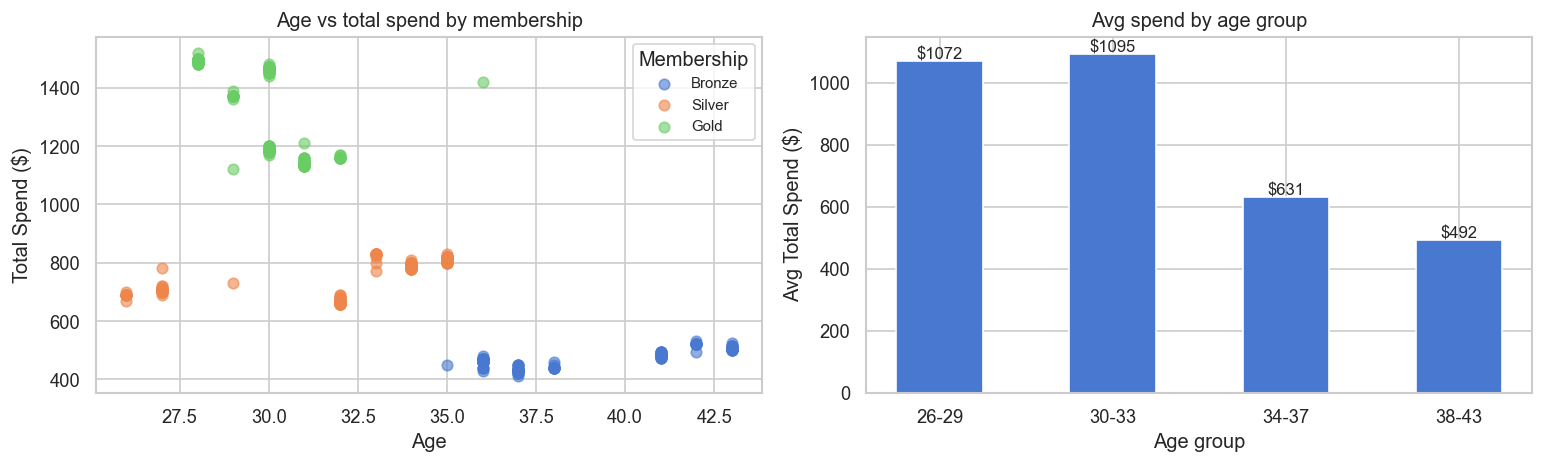

In [15]:
# create age groups
df['Age Group'] = pd.cut(df['Age'], bins=[25, 29, 33, 37, 44],
                          labels=['26-29', '30-33', '34-37', '38-43'])

fig, axes = plt.subplots(1, 2, figsize=(13, 4))

# scatter: age vs spend coloured by membership
for i, mem in enumerate(mem_order):
    subset = df[df['Membership Type'] == mem]
    axes[0].scatter(subset['Age'], subset['Total Spend'],
                    label=mem, alpha=0.6, s=40, color=palette[i])
axes[0].set_title('Age vs total spend by membership')
axes[0].set_xlabel('Age')
axes[0].set_ylabel('Total Spend ($)')
axes[0].legend(title='Membership', fontsize=9)

# avg spend by age group
age_spend = df.groupby('Age Group', observed=True)['Total Spend'].mean()
axes[1].bar(age_spend.index.astype(str), age_spend.values,
            color=sns.color_palette('muted')[0], width=0.5)
axes[1].set_title('Avg spend by age group')
axes[1].set_xlabel('Age group')
axes[1].set_ylabel('Avg Total Spend ($)')
for i, val in enumerate(age_spend.values):
    axes[1].text(i, val + 5, f'${val:.0f}', ha='center', fontsize=10)

plt.tight_layout()
plt.savefig('../outputs/05_age_spending.png', bbox_inches='tight')
plt.show()

The scatter plot makes it very obvious — spend is determined by membership tier, not age. Within each tier, age doesn't matter much. The three bands (Gold, Silver, Bronze) are clearly separated regardless of age.

---

## 7. Satisfaction analysis

In [16]:
sat_stats = df.groupby('Satisfaction Level').agg(
    Count     = ('Customer ID', 'count'),
    Avg_Spend = ('Total Spend', 'mean'),
    Avg_Items = ('Items Purchased', 'mean'),
    Avg_Rating= ('Average Rating', 'mean')
).round(2)
print(sat_stats)

                    Count  Avg_Spend  Avg_Items  Avg_Rating
Satisfaction Level                                         
Neutral               107     616.41       9.44        3.66
Satisfied             125    1280.32      17.32        4.65
Unsatisfied           116     595.14      10.53        3.69


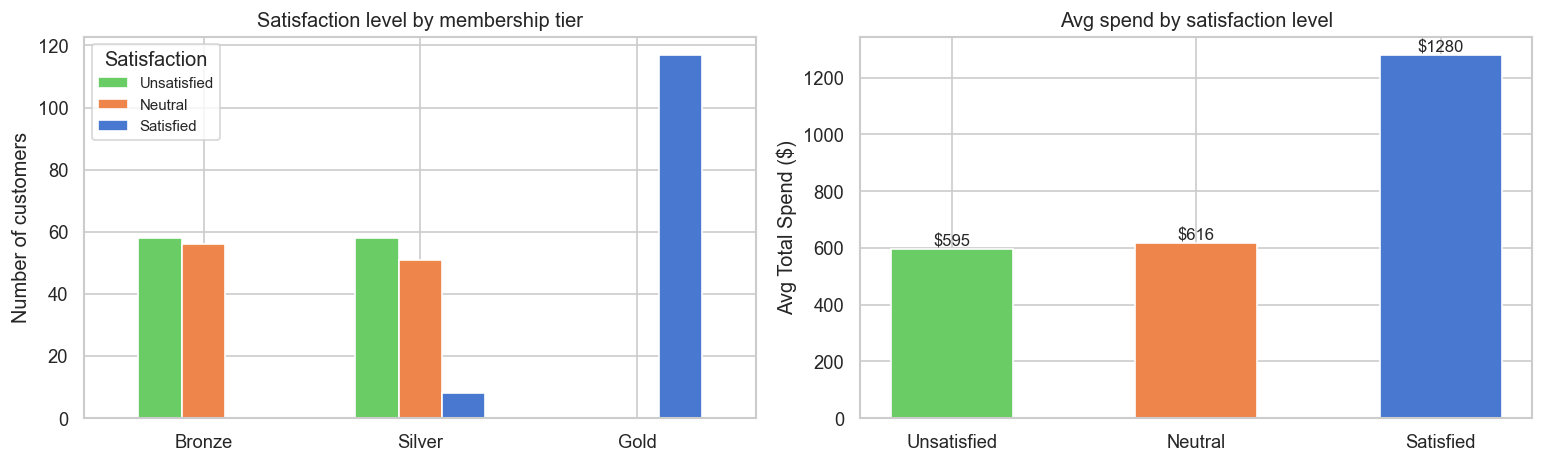

In [17]:
fig, axes = plt.subplots(1, 2, figsize=(13, 4))
sat_order  = ['Unsatisfied', 'Neutral', 'Satisfied']
sat_palette = [sns.color_palette('muted')[2], sns.color_palette('muted')[1], sns.color_palette('muted')[0]]

# satisfaction by membership tier
sat_mem = df.groupby(['Membership Type', 'Satisfaction Level']).size().unstack().fillna(0)
sat_mem = sat_mem.reindex(index=mem_order, columns=sat_order)
sat_mem.plot(kind='bar', ax=axes[0], color=sat_palette, width=0.6)
axes[0].set_title('Satisfaction level by membership tier')
axes[0].set_ylabel('Number of customers')
axes[0].set_xlabel('')
axes[0].tick_params(axis='x', rotation=0)
axes[0].legend(title='Satisfaction', fontsize=9)

# avg spend by satisfaction
sat_spend = df.groupby('Satisfaction Level')['Total Spend'].mean().reindex(sat_order)
bars = axes[1].bar(sat_order, sat_spend.values, color=sat_palette, width=0.5)
axes[1].set_title('Avg spend by satisfaction level')
axes[1].set_ylabel('Avg Total Spend ($)')
for bar, val in zip(bars, sat_spend.values):
    axes[1].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 10,
                 f'${val:.0f}', ha='center', fontsize=10)

plt.tight_layout()
plt.savefig('../outputs/06_satisfaction_analysis.png', bbox_inches='tight')
plt.show()

Satisfied customers spend significantly more ($1,100+) than Unsatisfied ones (~$500). And Gold members are mostly Satisfied while Bronze members skew Unsatisfied. This makes sense — higher tier members get more benefits and spend more, so they're naturally happier.

---

## 8. Summary

In [18]:
total_customers  = len(df)
total_spend      = df['Total Spend'].sum()
avg_spend        = df['Total Spend'].mean()
repeat_pct       = (df['Days Since Last Purchase'] < 30).mean() * 100
top_city         = df.groupby('City')['Total Spend'].mean().idxmax()
discount_uplift  = df[df['Discount Applied']==False]['Total Spend'].mean() - df[df['Discount Applied']==True]['Total Spend'].mean()

print('=== Summary ===')
print(f'Total customers:              {total_customers}')
print(f'Total spend across all:       ${total_spend:,.2f}')
print(f'Average spend per customer:   ${avg_spend:.2f}')
print(f'Recent buyers (< 30 days):    {repeat_pct:.1f}%')
print(f'Highest avg spend city:       {top_city}')
print(f'Non-discount spend premium:   ${discount_uplift:.2f} more than discount customers')

=== Summary ===
Total customers:              350
Total spend across all:       $295,883.60
Average spend per customer:   $845.38
Recent buyers (< 30 days):    64.0%
Highest avg spend city:       San Francisco
Non-discount spend premium:   $116.22 more than discount customers


## What I'd do next

- Apply KMeans clustering to group customers by spend + items purchased + recency — that would give more nuanced segments than just Bronze/Silver/Gold
- Build a logistic regression model to predict satisfaction level from the other features
- The discount finding is interesting enough to investigate further — does discount usage vary by city? By age group?
- With more data (actual transaction history rather than aggregated spend), repeat purchase rate could be calculated properly